In [11]:
import scanpy as sc
import pandas as pd
import infercnvpy as cnv

import sys
import os 
sys.path.append(os.path.expanduser(f"~/storage3/augusta/insituCNV/InSituCNV"))
import insitucnv as icv
from insitucnv import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Read in datasets

In [2]:
print('reading snpathoseq...')
adata_snpatho = sc.read(os.path.expanduser("~/storage3/augusta/insituCNV/InSituCNV/Colorectal_cancer_CosMxWTx/01_insituCNV/data/snPATHOseq_221_common_CNVinf.h5ad"))


reading snpathoseq...


In [ ]:
print('reading cosmx..')
adata_cosmx = sc.read(os.path.expanduser("~/storage3/augusta/insituCNV/InSituCNV/Colorectal_cancer_CosMxWTx/01_insituCNV/data/CosMx_221_common_CNVinf.h5ad"))

In [3]:
adata_snpatho

AnnData object with n_obs × n_vars = 2094 × 14044
    obs: 'pid', 'run', 'sid', 'sum', 'detected', 'subsets_mt_sum', 'subsets_mt_detected', 'subsets_mt_percent', 'total', 'sizeFactor', 'kid', 'decontX_contamination', 'decontX_clusters', 'sum.1', 'detected.1', 'subsets_mt_sum.1', 'subsets_mt_detected.1', 'subsets_mt_percent.1', 'total.1', 'scDblFinder.sample', 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', 'lv1', 'barcode', 'epi_cnv_leiden_res0.01'
    var: 'ensembl_id', 'gene_symbol', 'subsets_mt', 'gene_id', 'symbol', 'ensg', 'chromosome', 'start', 'end'
    uns: 'X_name', 'cnv', 'dendrogram_epi_cnv_leiden_res0.01', 'epi_cnv_leiden_res0.01_colors', 'log1p', 'lv1_colors', 'neighbors', 'scDblFinder.stats', 'scDblFinder.threshold', 'sid_colors'
    obsm: 'PCA', 'UMAP', 'X_cnv', 'X_pca', 'X_umap'
    layers: 'M', 'X', 'logcounts', 'no

In [6]:
adata_cosmx

AnnData object with n_obs × n_vars = 347023 × 14044
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantil

## Annotate the CNV clusters containing tumor cells

### CosMx

In [7]:
adata_cosmx.obs['epi_cnv_leiden_res0.1']

c_2_1_2               1
c_2_1_5               1
c_2_1_7               1
c_2_1_8               1
c_2_1_9               1
                 ...   
c_2_209_1539          0
c_2_209_1541          1
c_2_209_1542    non-epi
c_2_209_1543          0
c_2_209_1544          1
Name: epi_cnv_leiden_res0.1, Length: 347023, dtype: category
Categories (5, object): ['0', '1', '2', '3', 'non-epi']

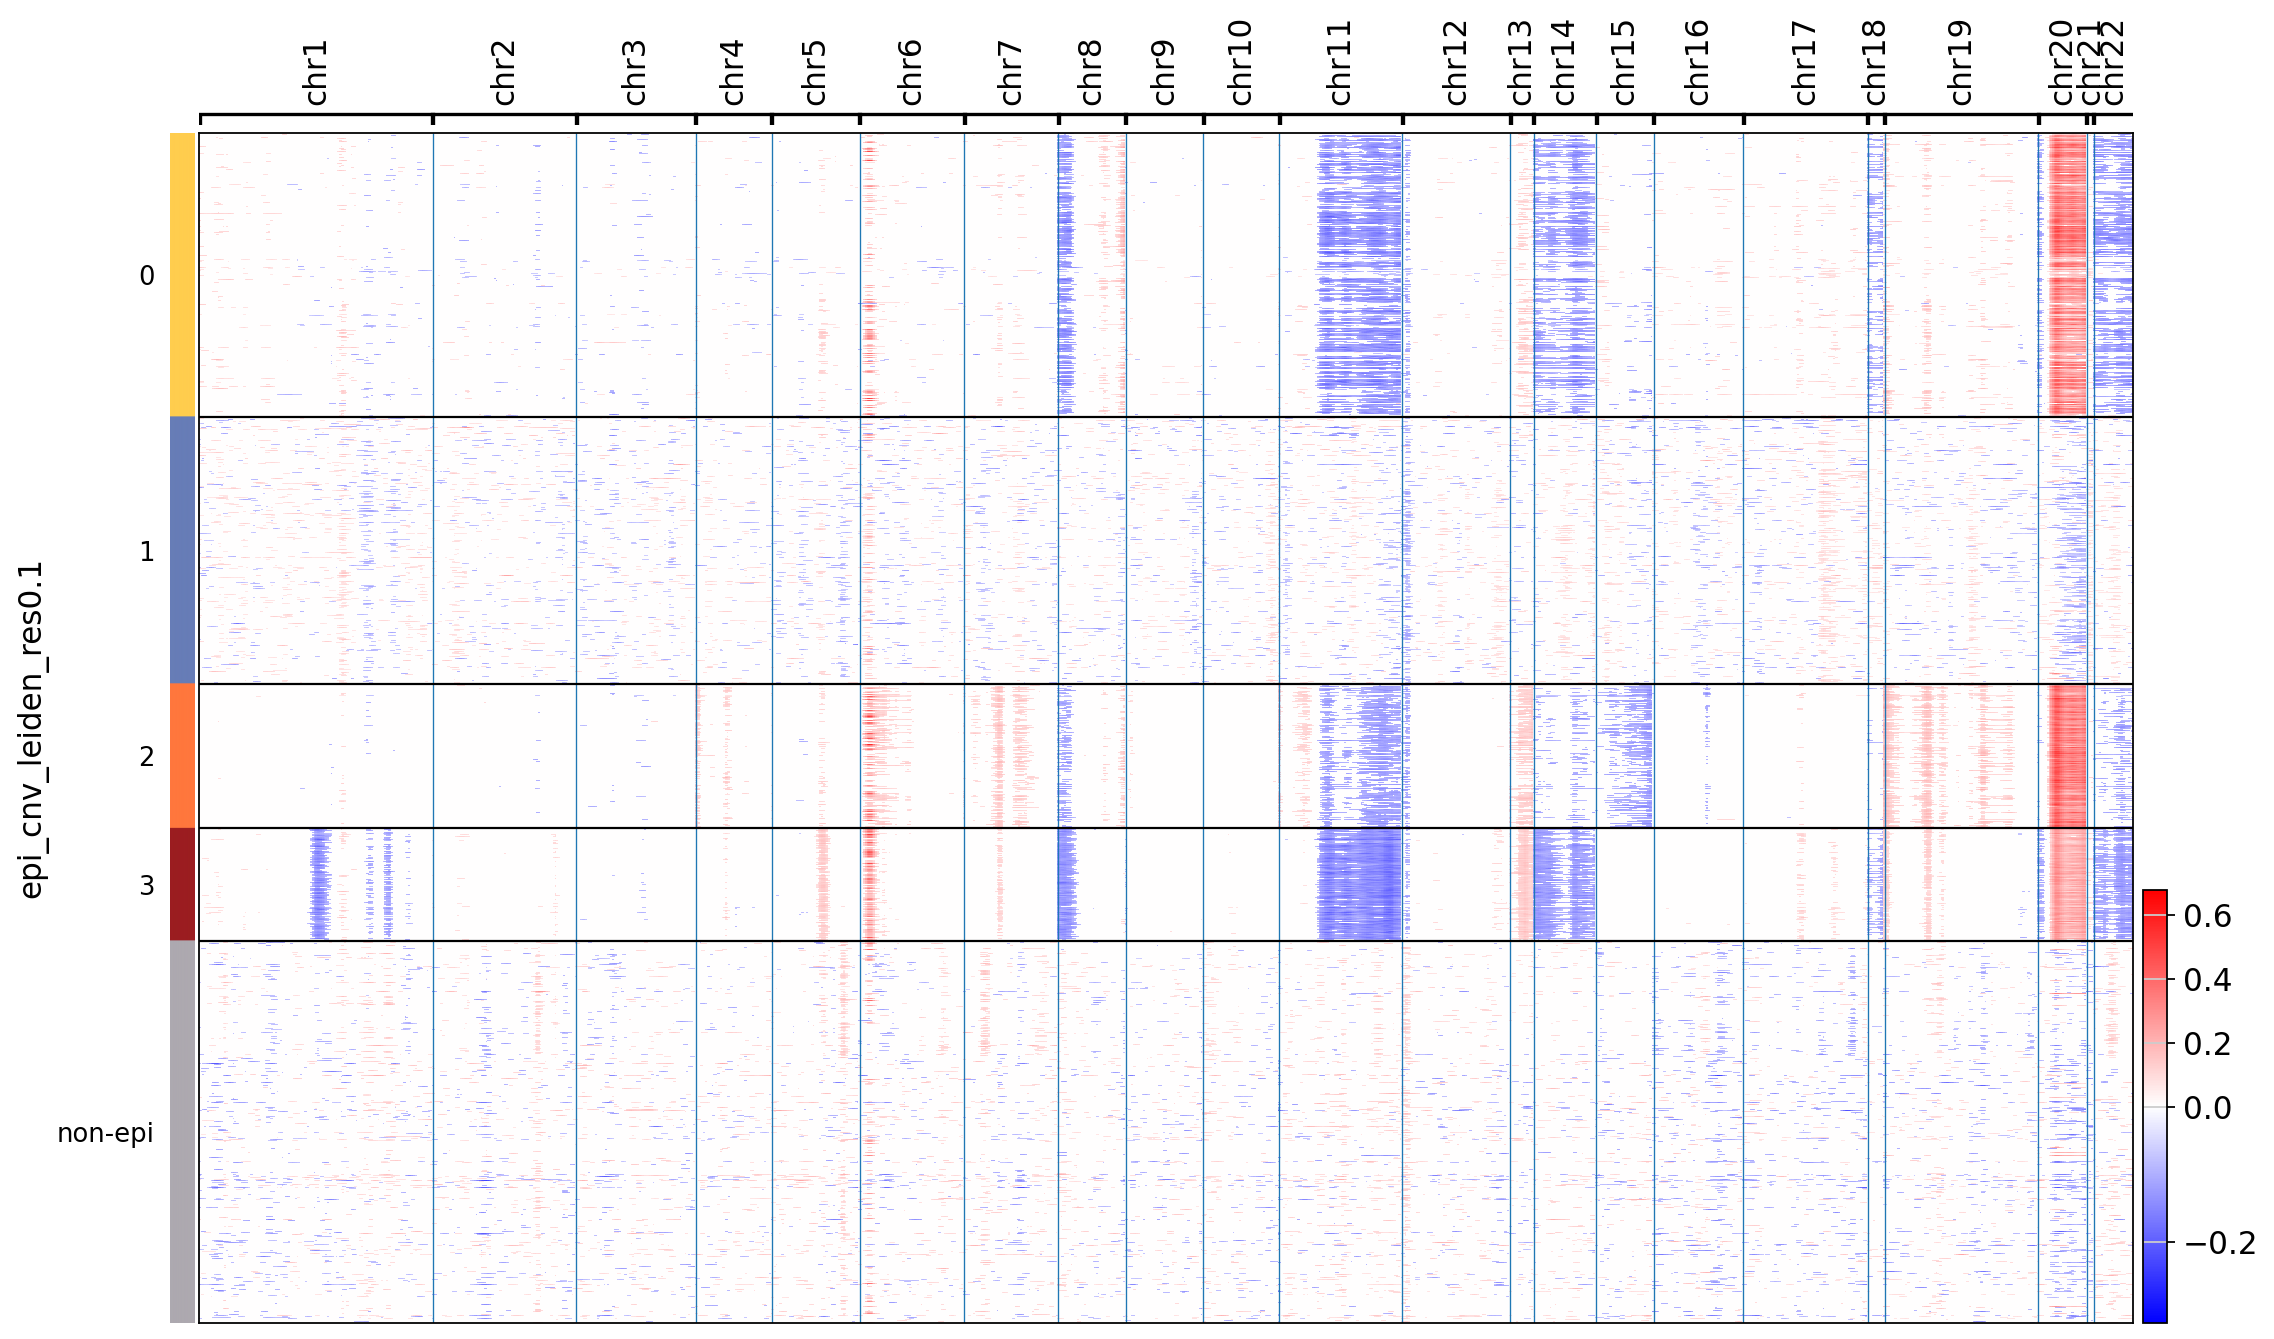

In [23]:
cnv.pl.chromosome_heatmap(adata_cosmx, groupby = 'epi_cnv_leiden_res0.1')

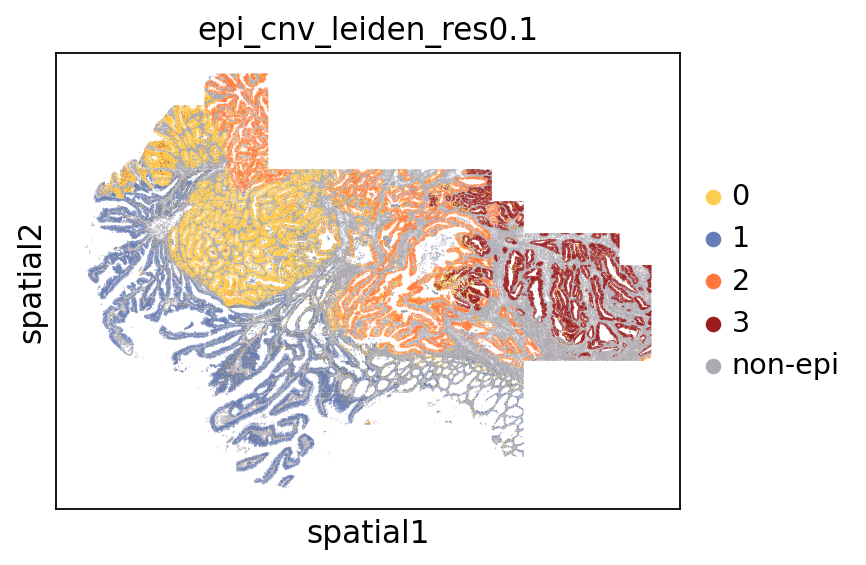

In [24]:
sc.pl.spatial(adata_cosmx, color='epi_cnv_leiden_res0.1', spot_size=100)

In [25]:
import numpy as np

adata_cosmx.obs['cnv_status'] = np.where(
    adata_cosmx.obs['epi_cnv_leiden_res0.1'].isin(['0','2','3']),
    'tumor',
    'normal'
)

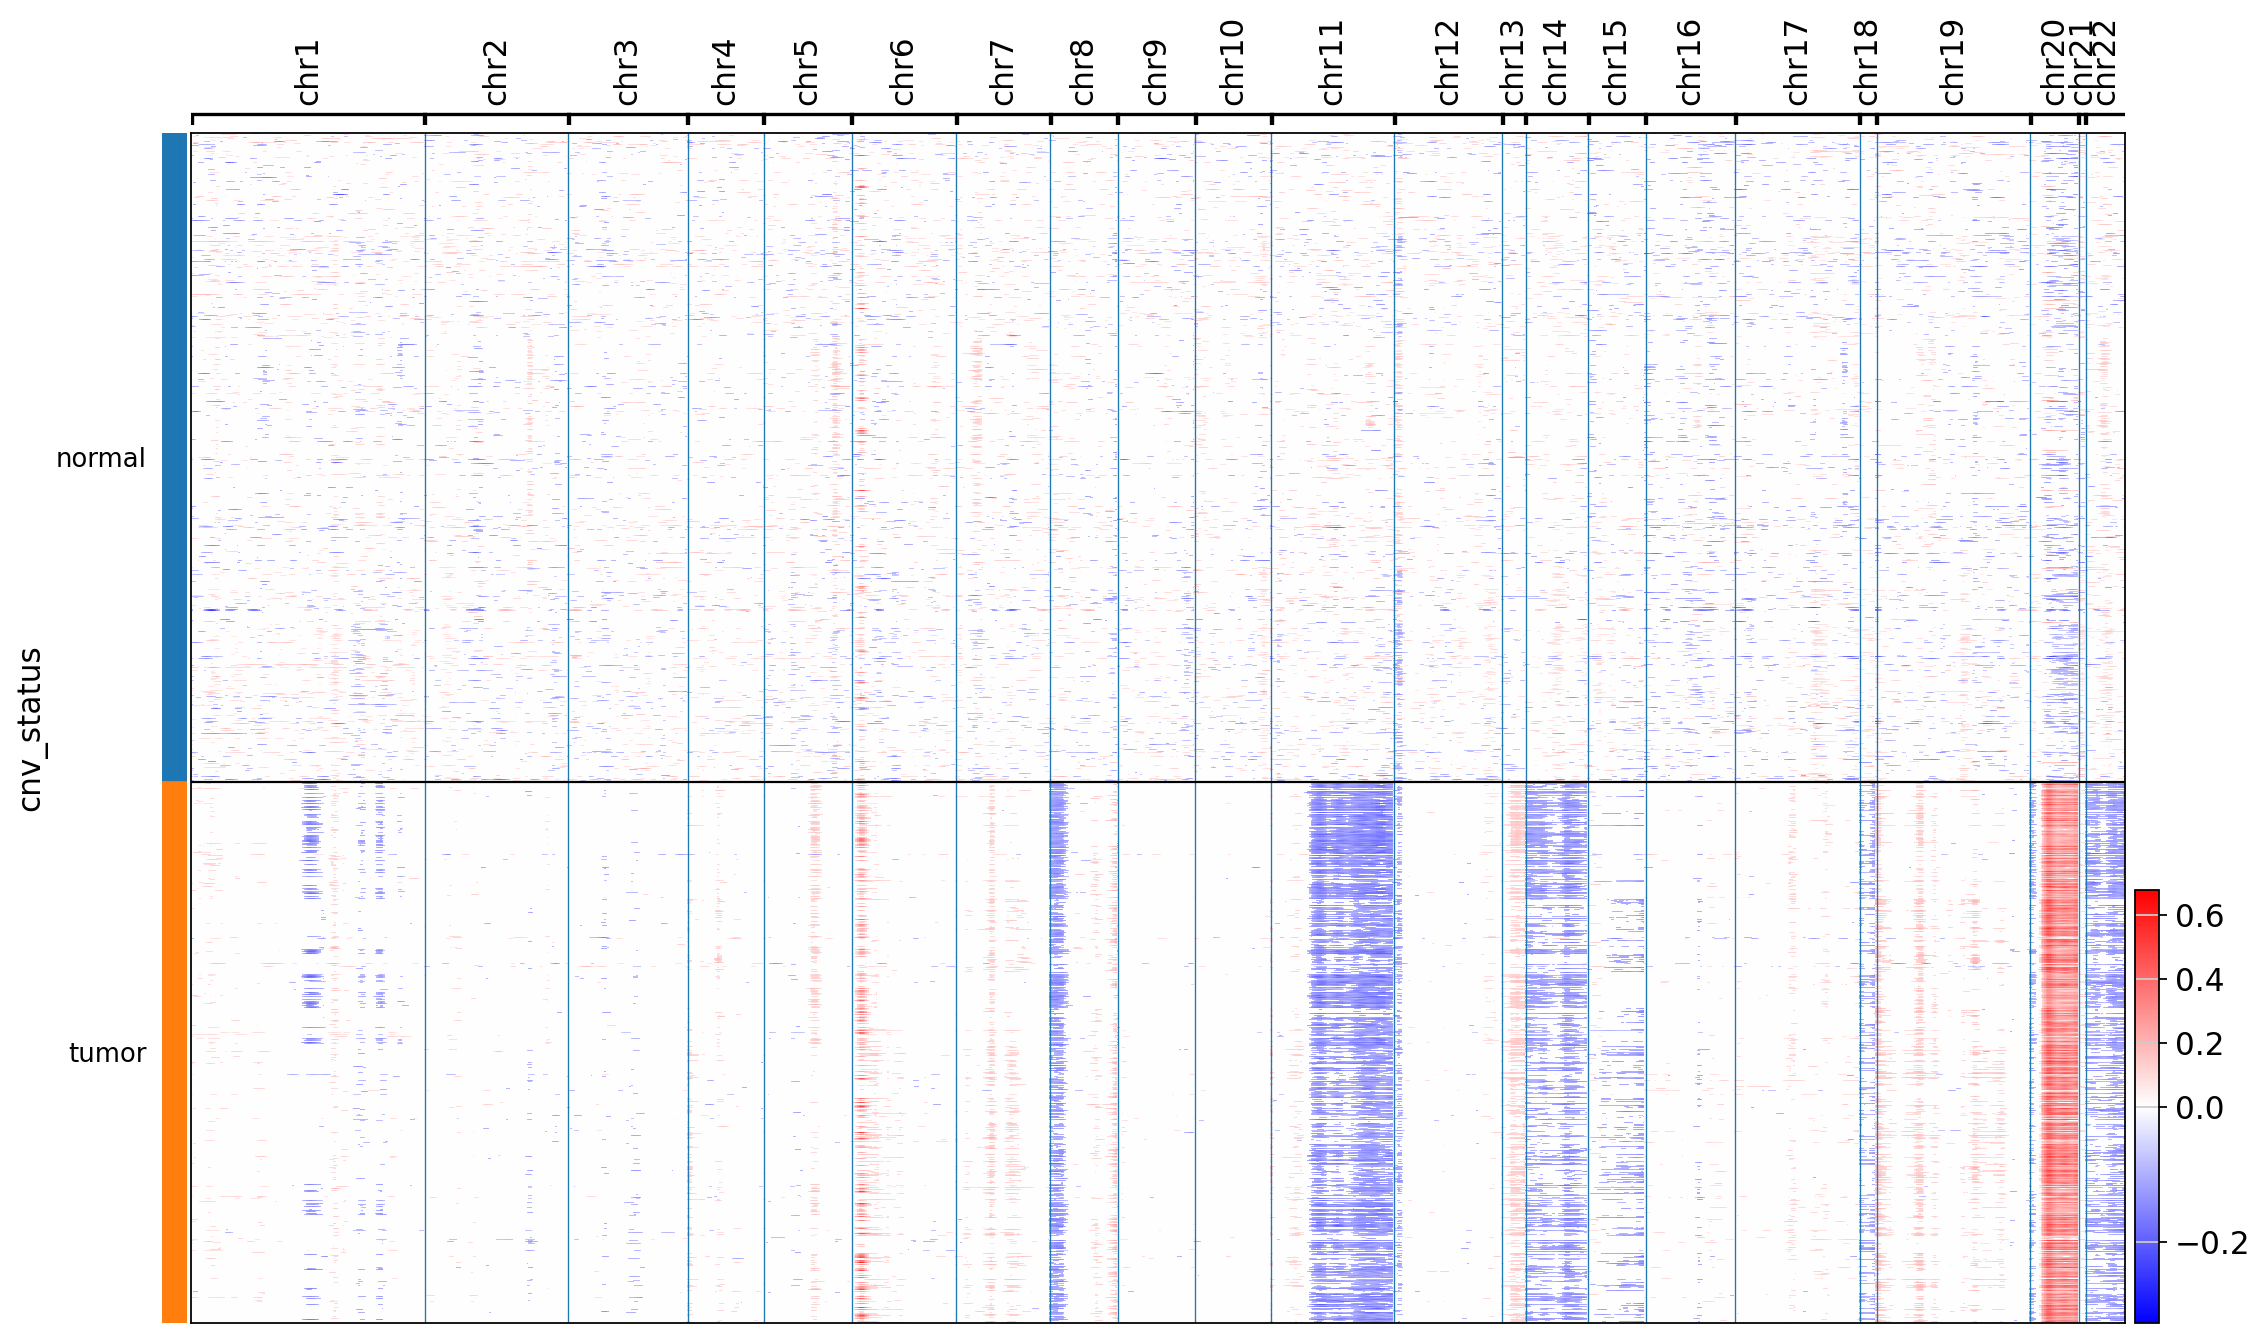

In [26]:
cnv.pl.chromosome_heatmap(adata_cosmx, groupby = 'cnv_status')

### snPATHOseq

In [4]:
adata_snpatho.obs['epi_cnv_leiden_res0.01']

B1914093_B1-2.AAACAAGCAAAGCTCAAGTAGGCT-1          0
B1914093_B1-2.AAACAAGCATATAGGTAGTAGGCT-1          0
B1914093_B1-2.AAACCAATCATTTGCGAGTAGGCT-1    non-epi
B1914093_B1-2.AAACGGGCAACCTGTTAGTAGGCT-1    non-epi
B1914093_B1-2.AAACGTTCAACAGCACAGTAGGCT-1    non-epi
                                             ...   
B1914093_B1-2.TTTGCTGAGGAGCCGTAGTAGGCT-1    non-epi
B1914093_B1-2.TTTGCTGAGTTGGCCTAGTAGGCT-1          0
B1914093_B1-2.TTTGGACGTCAACTACAGTAGGCT-1          0
B1914093_B1-2.TTTGTGAGTGAGTAATAGTAGGCT-1    non-epi
B1914093_B1-2.TTTGTGAGTGGACCCTAGTAGGCT-1          0
Name: epi_cnv_leiden_res0.01, Length: 2094, dtype: category
Categories (2, object): ['0', 'non-epi']

In [5]:
adata_snpatho

AnnData object with n_obs × n_vars = 2094 × 14044
    obs: 'pid', 'run', 'sid', 'sum', 'detected', 'subsets_mt_sum', 'subsets_mt_detected', 'subsets_mt_percent', 'total', 'sizeFactor', 'kid', 'decontX_contamination', 'decontX_clusters', 'sum.1', 'detected.1', 'subsets_mt_sum.1', 'subsets_mt_detected.1', 'subsets_mt_percent.1', 'total.1', 'scDblFinder.sample', 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', 'lv1', 'barcode', 'epi_cnv_leiden_res0.01'
    var: 'ensembl_id', 'gene_symbol', 'subsets_mt', 'gene_id', 'symbol', 'ensg', 'chromosome', 'start', 'end'
    uns: 'X_name', 'cnv', 'dendrogram_epi_cnv_leiden_res0.01', 'epi_cnv_leiden_res0.01_colors', 'log1p', 'lv1_colors', 'neighbors', 'scDblFinder.stats', 'scDblFinder.threshold', 'sid_colors'
    obsm: 'PCA', 'UMAP', 'X_cnv', 'X_pca', 'X_umap'
    layers: 'M', 'X', 'logcounts', 'no

categories: 0, non-epi
var_group_labels: chr1, chr2, chr3, etc.


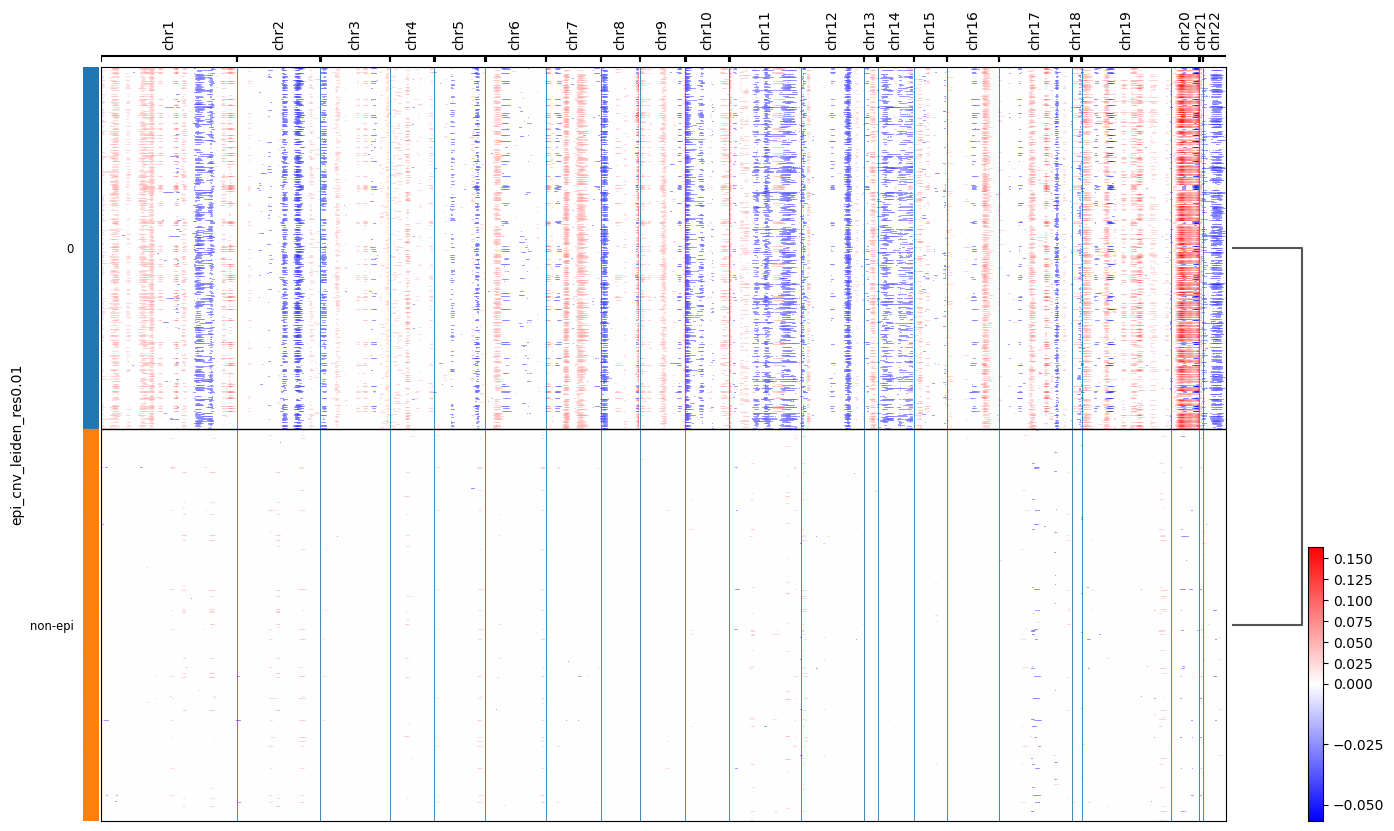

In [6]:
cnv.pl.chromosome_heatmap(adata_snpatho, groupby = 'epi_cnv_leiden_res0.01', dendrogram = True)

In [8]:
import numpy as np

adata_snpatho.obs['cnv_status'] = np.where(
    adata_snpatho.obs['epi_cnv_leiden_res0.01'].isin(['0']),
    'tumor',
    'normal'
)

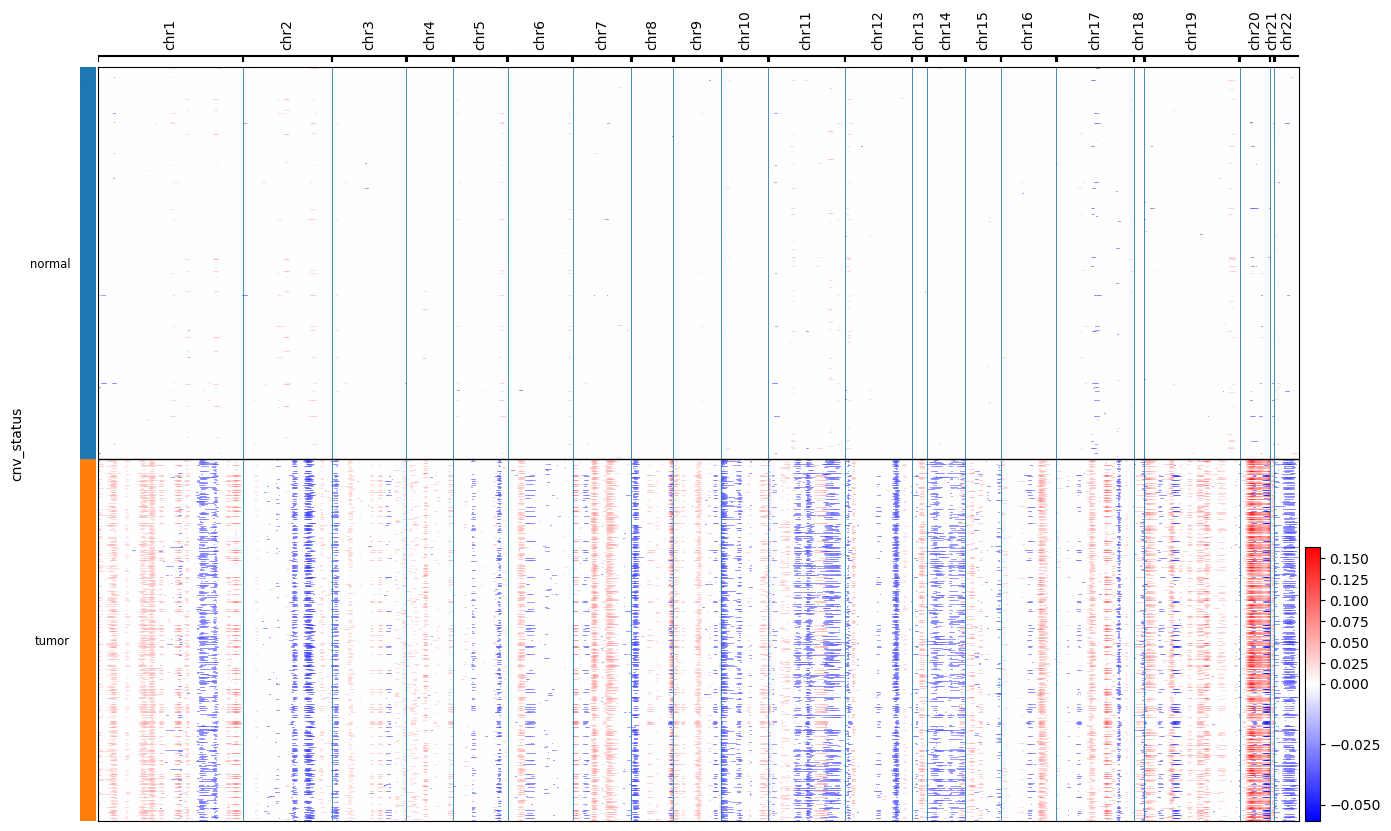

In [9]:
cnv.pl.chromosome_heatmap(adata_snpatho, groupby = 'cnv_status')

## Compute the average CNV profiles for each CNV cluster

In [ ]:
cosmx_cnv_profiles = icv.tl.compute_avg_cnv_profiles(adata_cosmx, group_by='cnv_status', label='CosMx')

In [12]:
snpatho_cnv_profiles = icv.tl.compute_avg_cnv_profiles(adata_snpatho, group_by='cnv_status', label='snPATHOseq')

In [28]:
cosmx_cnv_profiles

{'CosMx_normal':       bin_index chromosome  mean_cnv   std_cnv        source
 0             0       chr1 -0.002584  0.027975  CosMx_normal
 1             1       chr1 -0.001776  0.025365  CosMx_normal
 2             2       chr1 -0.001459  0.024013  CosMx_normal
 3             3       chr1 -0.001188  0.022328  CosMx_normal
 4             4       chr1 -0.000903  0.021398  CosMx_normal
 ...         ...        ...       ...       ...           ...
 1142       1142      chr22  0.001997  0.025125  CosMx_normal
 1143       1143      chr22  0.002291  0.025509  CosMx_normal
 1144       1144      chr22  0.002522  0.026953  CosMx_normal
 1145       1145      chr22  0.002594  0.027520  CosMx_normal
 1146       1146      chr22  0.002402  0.028505  CosMx_normal
 
 [1147 rows x 5 columns],
 'CosMx_tumor':       bin_index chromosome  mean_cnv   std_cnv       source
 0             0       chr1  0.004445  0.021104  CosMx_tumor
 1             1       chr1  0.003625  0.018984  CosMx_tumor
 2            

## Compute and plot similarity matrix of the CNV clusters from CosMx vs snPATHO-seq

In [13]:
similarity_matrix = icv.tl.compute_cnv_similarity_matrix(snpatho_cnv_profiles, cosmx_cnv_profiles)
similarity_matrix

NameError: name 'cosmx_cnv_profiles' is not defined

In [30]:
# Save 
similarity_matrix.to_csv("cnv_cosine_similarity_matrix.csv")

In [31]:
similarity_matrix = pd.read_csv("cnv_cosine_similarity_matrix.csv", index_col=0)
similarity_matrix

,CosMx_normal,CosMx_tumor
snPATHOseq_normal,0.185546,-0.162135
snPATHOseq_tumor,-0.421013,0.782168


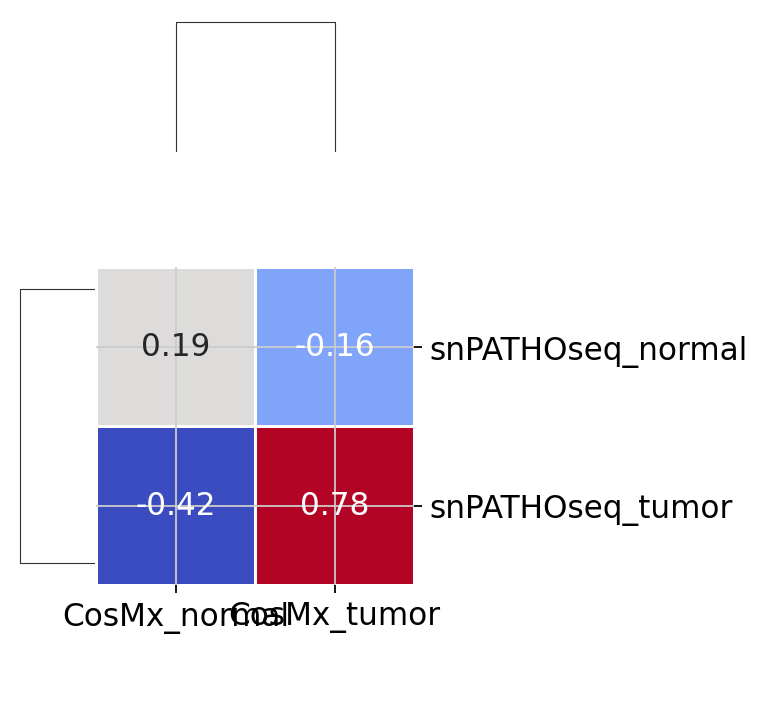

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting clustered heatmap
g = sns.clustermap(similarity_matrix
                    .drop(index='snPATHOseq_non-epi', errors='ignore')
                    .drop(columns='CosMx_non-epi', errors='ignore'),
                   annot=True, 
                   fmt=".2f", 
                   cmap="coolwarm", 
                   figsize=(5, 5),
                   cbar_pos=None,
                   linewidths=0.5,
                   row_cluster=True, 
                   col_cluster=True)

g.ax_heatmap.set_aspect('equal')

# plt.savefig('snpathoseq_vs_cosmx_cosine_similarity_matrix.pdf')
plt.show()

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Select the malignant clusters
malignant_cosmx_clusters = ['CosMx_tumor']
malignant_snpatho_clusters = ['snPATHOseq_tumor']


# Compute averaged profiles
avg_snpatho = icv.tl.average_profiles(malignant_snpatho_clusters, snpatho_cnv_profiles)
avg_cosmx = icv.tl.average_profiles(malignant_cosmx_clusters, cosmx_cnv_profiles)

In [34]:
avg_cosmx.head()

,bin_index,chromosome,mean_cnv
0,0,chr1,0.004445
1,1,chr1,0.003625
2,2,chr1,0.003111
3,3,chr1,0.002103
4,4,chr1,0.001825


In [35]:
avg_cosmx.to_csv("cosmx_tumor_cells_mean_cnv_per_bin.csv")

In [36]:
avg_snpatho.head()

,bin_index,chromosome,mean_cnv
0,0,chr1,0.009107
1,1,chr1,0.010062
2,2,chr1,0.008055
3,3,chr1,0.003611
4,4,chr1,0.001910


In [37]:
avg_snpatho.to_csv("snpatho_tumor_cells_mean_cnv_per_bin.csv")

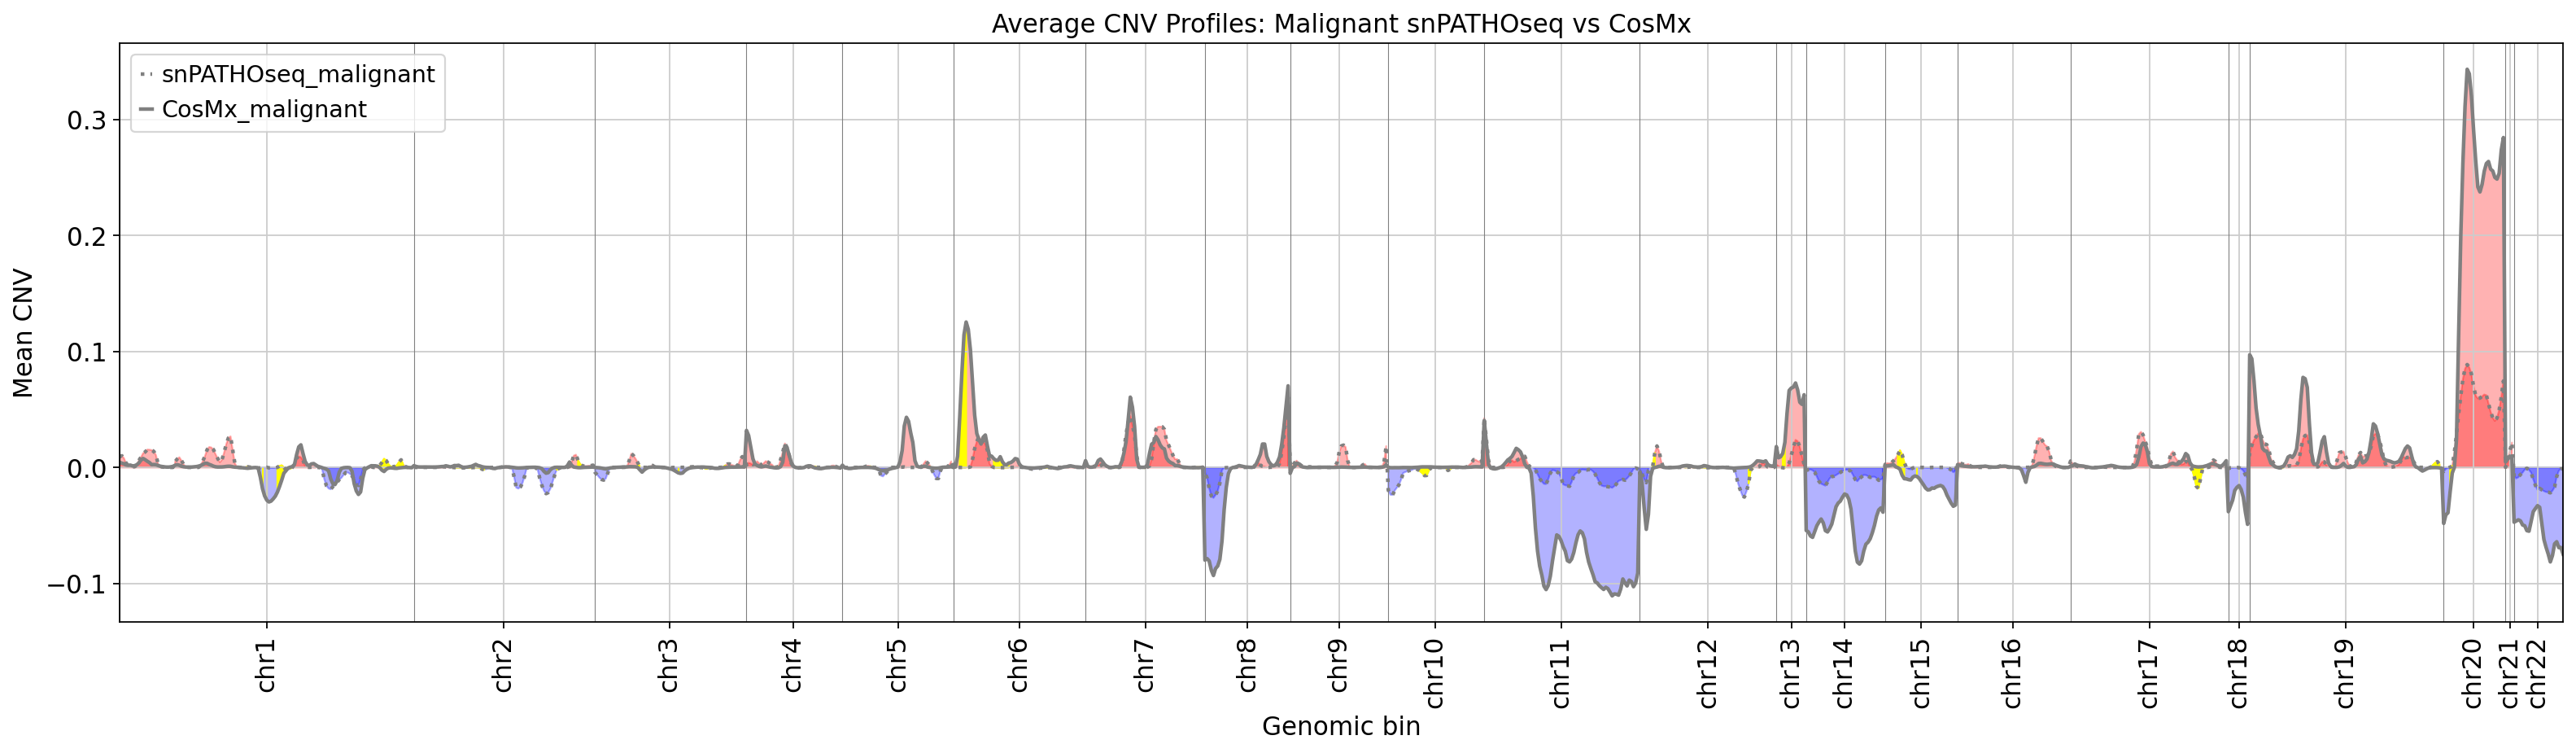

In [38]:
icv.tl.plot_avg_cnv_comparison(
    df1 = avg_snpatho,
    df2 = avg_cosmx,
    chr_pos=adata_snpatho.uns['cnv']['chr_pos'],
    label1='snPATHOseq_malignant',
    label2='CosMx_malignant',
    title='Average CNV Profiles: Malignant snPATHOseq vs CosMx',
    save_path='avg_cnv_malignant_comparison.pdf'
)